In [1]:
import json
import ssl
import urllib.parse
import urllib.request

import certifi

params = urllib.parse.urlencode(
    {
        "start": "1",
        "limit": "15",
        "convert": "USD",
    }
)

request = urllib.request.Request(
    f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
    headers={
        "Accept": "application/json",
        "X-CMC_PRO_API_KEY": "c1c1a5d523224c748117dd3e227a2c86",
    },
)

context = ssl.create_default_context(cafile=certifi.where())

with urllib.request.urlopen(request, context=context) as response:
    data = json.load(response)

print(data)

{'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'infinite_supply': False, 'circulating_supply': 20064187, 'total_supply': 20064187, 'max_supply': 21000000, 'date_added': '2010-07-13T00:00:00.000Z', 'num_market_pairs': 12678, 'cmc_rank': 1, 'last_updated': '2026-08-01T10:29:00.000Z', 'tvl_ratio': None, 'platform': None, 'self_reported_circulating_supply': None, 'self_reported_market_cap': None, 'minted_market_cap': 1263625686544.19, 'quote': {'USD': {'price': 62979.16215315327, 'volume_24h': 22921733143.099854, 'cex_volume_24h': 22889976367.737057, 'dex_volume_24h': 31756775.36279596, 'volume_change_24h': -15.7127, 'percent_change_1h': -0.10875593, 'percent_change_24h': -1.22295036, 'percent_change_7d': -1.54863506, 'percent_change_30d': 3.0209493, 'percent_change_60d': -9.41880301, 'percent_change_90d': -19.68825685, 'market_cap': 1263625686544.19, 'market_cap_dominance': 58.4799, 'fully_diluted_market_cap': 1322562405216.22, 'tvl': None, 'last_updated': '202

In [2]:
type(data)

dict

In [3]:
import pandas as pd

#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
#This normalizes the data and makes it all pretty in a dataframe

df = pd.json_normalize(data['data'])
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address
0,1,Bitcoin,BTC,bitcoin,False,2.006419e+07,2.006419e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12678,1,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.263626e+12,"[mineable, pow, sha-256, store-of-value, state...",62979.162153,2.292173e+10,2.288998e+10,3.175678e+07,-15.7127,-0.108756,-1.222950,-1.548635,3.020949,-9.418803,-19.688257,1.263626e+12,58.4799,1.322562e+12,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN
1,1027,Ethereum,ETH,ethereum,True,1.206823e+08,1.206823e+08,NaN,2015-08-07T00:00:00.000Z,12294,2,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,2.249036e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1863.601375,7.573442e+09,7.517598e+09,5.584362e+07,-12.7594,-0.240652,-1.137319,0.415128,13.461640,-5.670583,-19.364101,2.249036e+11,10.4084,2.249036e+11,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN
2,825,Tether USDt,USDT,tether,True,1.834577e+11,1.891058e+11,NaN,2015-02-25T00:00:00.000Z,192664,3,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,1.889349e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999096,4.497085e+10,4.391098e+10,1.059870e+09,-15.1964,0.009587,0.018473,0.014606,0.043767,0.065658,-0.062208,1.832918e+11,8.4826,1.889349e+11,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7
3,1839,BNB,BNB,bnb,False,1.331652e+08,1.331652e+08,1.331652e+08,2017-07-25T00:00:00.000Z,3322,4,2026-08-01T10:27:00.000Z,None,NaN,NaN,NaN,7.754131e+10,"[marketplace, centralized-exchange, payments, ...",582.293938,1.078512e+09,1.056726e+09,2.178651e+07,-27.0206,-0.436336,-1.246625,3.023664,4.927035,-13.906376,-5.771019,7.754131e+10,3.5880,7.754131e+10,None,2026-08-01T10:27:00.000Z,NaN,NaN,NaN,NaN,NaN
4,3408,USDC,USDC,usd-coin,False,7.194245e+10,7.194245e+10,NaN,2018-10-08T00:00:00.000Z,41979,5,2026-08-01T10:28:00.000Z,None,NaN,6.090122e+10,6.089182e+10,7.193134e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999846,7.681606e+09,6.598883e+09,1.082723e+09,-13.2782,0.005860,0.009102,-0.007166,0.013494,0.016888,0.024524,7.193134e+10,3.3289,7.193134e+10,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48
5,52,XRP,XRP,xrp,False,6.253327e+10,9.998564e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1852,6,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.061757e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.061910,9.232583e+08,9.227898e+08,4.684941e+05,-12.9298,0.065228,-0.887197,-2.461876,-1.117099,-15.874188,-23.532235,6.640468e+10,3.0732,1.061910e+11,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN
6,5426,Solana,SOL,solana,True,5.810787e+08,6.313762e+08,NaN,2020-04-10T00:00:00.000Z,1148,7,2026-08-01T10:28:00.000Z,None,NaN,5.252369e+08,3.822625e+10,4.595097e+10,"[pos, platform, solana-ecosystem, cms-holdings...",72.779057,1.259845e+09,1.259761e+09,8.413258e+04,-22.3711,-0.173858,-1.026444,-1.513556,-9.309121,-8.132526,-13.310903,4.229036e+10,1.9572,4.595097e+10,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN
7,1958,TRON,TRX,tron,True,9.488834e+10,9.488834e+10,NaN,2017-09-13T00:00:00.000Z,1355,8,2026-08-01T10:29:00.000Z,None,NaN,9.466789e+10,3.102507e+10,3.109732e+10,"[media, payments, tron-ecosystem, layer-1, dwf...",0.327725,4.347578e+08,4.347325e+08,2.526115e+04,-7.4606,0.084793,0.493615,-0.545295,3.564911,-3.7645

In [5]:
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.006419e+07,2.006419e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12678,1,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.263626e+12,"[mineable, pow, sha-256, store-of-value, state...",62979.162153,2.292173e+10,2.288998e+10,3.175678e+07,-15.7127,-0.108756,-1.222950,-1.548635,3.020949,-9.418803,-19.688257,1.263626e+12,58.4799,1.322562e+12,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730
1,1027,Ethereum,ETH,ethereum,True,1.206823e+08,1.206823e+08,NaN,2015-08-07T00:00:00.000Z,12294,2,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,2.249036e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1863.601375,7.573442e+09,7.517598e+09,5.584362e+07,-12.7594,-0.240652,-1.137319,0.415128,13.461640,-5.670583,-19.364101,2.249036e+11,10.4084,2.249036e+11,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730
2,825,Tether USDt,USDT,tether,True,1.834577e+11,1.891058e+11,NaN,2015-02-25T00:00:00.000Z,192664,3,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,1.889349e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999096,4.497085e+10,4.391098e+10,1.059870e+09,-15.1964,0.009587,0.018473,0.014606,0.043767,0.065658,-0.062208,1.832918e+11,8.4826,1.889349e+11,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-01 10:30:13.804730
3,1839,BNB,BNB,bnb,False,1.331652e+08,1.331652e+08,1.331652e+08,2017-07-25T00:00:00.000Z,3322,4,2026-08-01T10:27:00.000Z,None,NaN,NaN,NaN,7.754131e+10,"[marketplace, centralized-exchange, payments, ...",582.293938,1.078512e+09,1.056726e+09,2.178651e+07,-27.0206,-0.436336,-1.246625,3.023664,4.927035,-13.906376,-5.771019,7.754131e+10,3.5880,7.754131e+10,None,2026-08-01T10:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730
4,3408,USDC,USDC,usd-coin,False,7.194245e+10,7.194245e+10,NaN,2018-10-08T00:00:00.000Z,41979,5,2026-08-01T10:28:00.000Z,None,NaN,6.090122e+10,6.089182e+10,7.193134e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999846,7.681606e+09,6.598883e+09,1.082723e+09,-13.2782,0.005860,0.009102,-0.007166,0.013494,0.016888,0.024524,7.193134e+10,3.3289,7.193134e+10,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-08-01 10:30:13.804730
5,52,XRP,XRP,xrp,False,6.253327e+10,9.998564e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1852,6,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.061757e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.061910,9.232583e+08,9.227898e+08,4.684941e+05,-12.9298,0.065228,-0.887197,-2.461876,-1.117099,-15.874188,-23.532235,6.640468e+10,3.0732,1.061910e+11,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730
6,5426,Solana,SOL,solana,True,5.810787e+08,6.313762e+08,NaN,2020-04-10T00:00:00.000Z,1148,7,2026-08-01T10:28:00.000Z,None,NaN,5.252369e+08,3.822625e+10,4.595097e+10,"[pos, platform, solana-ecosystem, cms-holdings...",72.779057,1.259845e+09,1.259761e+09,8.413258e+04,-22.3711,-0.173858,-1.026444,-1.513556,-9.309121,-8.132526,-13.310903,4.229036e+10,1.9572,4.595097e+10,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730
7,1958,TRON,TRX,tron,True,9.488834e+10,9.488834e+10,NaN,2017-09-13T00:00:00.000Z,1355,8,2026-08-01T10:29:00.000Z,N

In [6]:

def api_runner():
    global df
    params = urllib.parse.urlencode(
        {
            "start": "1",
            "limit": "15",
            "convert": "USD",
        }
    )

    request = urllib.request.Request(
        f"https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest?{params}",
        headers={
            "Accept": "application/json",
            "X-CMC_PRO_API_KEY": "c1c1a5d523224c748117dd3e227a2c86",
        },
    )

    context = ssl.create_default_context(cafile=certifi.where())

    with urllib.request.urlopen(request, context=context) as response:
        data = json.load(response)
 

    #NOTE:
    # I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
    # Into the Anaconda Prompt to change this to allow to pull data
    
    # Use this if you just want to keep it in a dataframe
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df = df.append(df2)


    # Use this if you want to create a csv and append data to it
    #df = pd.json_normalize(data['data'])
    #df['timestamp'] = pd.to_datetime('now')
    #df

    if not os.path.isfile(r'D:\0-AI\DataAnalyst\DataAnalyst_Portfolio\07-Data Analyst Projects\API.csv'):
        df2.to_csv(r'D:\0-AI\DataAnalyst\DataAnalyst_Portfolio\07-Data Analyst Projects\API.csv', header='column_names')
    else:
        df2.to_csv(r'D:\0-AI\DataAnalyst\DataAnalyst_Portfolio\07-Data Analyst Projects\API.csv', mode='a', header=False)
        
    #Then to read in the file: df = pd.read_csv(r'D:\0-AI\DataAnalyst\DataAnalyst_Portfolio\07-Data Analyst Projects\API.csv')

# If that didn't work try using the local host URL as shown in the video

In [7]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(30) #sleep for 1 minute
exit()

API Runner completed
API Runner completed


KeyboardInterrupt: 

In [8]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.006419e+07,2.006419e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12678,1,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.263626e+12,"[mineable, pow, sha-256, store-of-value, state...",62979.162153,2.292173e+10,2.288998e+10,3.175678e+07,-15.7127,-0.108756,-1.222950,-1.548635,3.020949,-9.418803,-19.688257,1.263626e+12,58.4799,1.322562e+12,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
1,1027,Ethereum,ETH,ethereum,True,1.206823e+08,1.206823e+08,NaN,2015-08-07T00:00:00.000Z,12294,2,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,2.249036e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",1863.601375,7.573442e+09,7.517598e+09,5.584362e+07,-12.7594,-0.240652,-1.137319,0.415128,13.461640,-5.670583,-19.364101,2.249036e+11,10.4084,2.249036e+11,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
2,825,Tether USDt,USDT,tether,True,1.834577e+11,1.891058e+11,NaN,2015-02-25T00:00:00.000Z,192664,3,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,1.889349e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999096,4.497085e+10,4.391098e+10,1.059870e+09,-15.1964,0.009587,0.018473,0.014606,0.043767,0.065658,-0.062208,1.832918e+11,8.4826,1.889349e+11,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-01 10:30:13.804730,NaT
3,1839,BNB,BNB,bnb,False,1.331652e+08,1.331652e+08,1.331652e+08,2017-07-25T00:00:00.000Z,3322,4,2026-08-01T10:27:00.000Z,None,NaN,NaN,NaN,7.754131e+10,"[marketplace, centralized-exchange, payments, ...",582.293938,1.078512e+09,1.056726e+09,2.178651e+07,-27.0206,-0.436336,-1.246625,3.023664,4.927035,-13.906376,-5.771019,7.754131e+10,3.5880,7.754131e+10,None,2026-08-01T10:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
4,3408,USDC,USDC,usd-coin,False,7.194245e+10,7.194245e+10,NaN,2018-10-08T00:00:00.000Z,41979,5,2026-08-01T10:28:00.000Z,None,NaN,6.090122e+10,6.089182e+10,7.193134e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999846,7.681606e+09,6.598883e+09,1.082723e+09,-13.2782,0.005860,0.009102,-0.007166,0.013494,0.016888,0.024524,7.193134e+10,3.3289,7.193134e+10,None,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-08-01 10:30:13.804730,NaT
5,52,XRP,XRP,xrp,False,6.253327e+10,9.998564e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1852,6,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1.061757e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.061910,9.232583e+08,9.227898e+08,4.684941e+05,-12.9298,0.065228,-0.887197,-2.461876,-1.117099,-15.874188,-23.532235,6.640468e+10,3.0732,1.061910e+11,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
6,5426,Solana,SOL,solana,True,5.810787e+08,6.313762e+08,NaN,2020-04-10T00:00:00.000Z,1148,7,2026-08-01T10:28:00.000Z,None,NaN,5.252369e+08,3.822625e+10,4.595097e+10,"[pos, platform, solana-ecosystem, cms-holdings...",72.779057,1.259845e+09,1.259761e+09,8.413258e+04,-22.3711,-0.173858,-1.026444,-1.513556,-9.309121,-8.132526,-13.310903,4.229036e+10,1.9572,4.595097e+10,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
7,1958,TRON,TRX,tron,True,9.488834e+10,9.488834e+10,NaN,2017-09-13T00:00:00.

In [9]:
df7 = pd.read_csv(r'D:\0-AI\DataAnalyst\DataAnalyst_Portfolio\07-Data Analyst Projects\API.csv')
df7

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,Timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,2.006419e+07,2.006419e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12678,1,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,1.263626e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",62979.162153,2.292173e+10,2.288998e+10,3.175678e+07,-15.7127,-0.108756,-1.222950,-1.548635,3.020949,-9.418803,-19.688257,1.263626e+12,58.4799,1.322562e+12,NaN,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:41.742859
1,1,1027,Ethereum,ETH,ethereum,True,1.206823e+08,1.206823e+08,NaN,2015-08-07T00:00:00.000Z,12294,2,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,2.249036e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",1863.601375,7.573442e+09,7.517598e+09,5.584362e+07,-12.7594,-0.240652,-1.137319,0.415128,13.461640,-5.670583,-19.364101,2.249036e+11,10.4084,2.249036e+11,NaN,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:41.742859
2,2,825,Tether USDt,USDT,tether,True,1.834577e+11,1.891058e+11,NaN,2015-02-25T00:00:00.000Z,192664,3,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,1.889349e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.999096,4.497085e+10,4.391098e+10,1.059870e+09,-15.1964,0.009587,0.018473,0.014606,0.043767,0.065658,-0.062208,1.832918e+11,8.4826,1.889349e+11,NaN,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-01 10:30:41.742859
3,3,1839,BNB,BNB,bnb,False,1.331652e+08,1.331652e+08,1.331652e+08,2017-07-25T00:00:00.000Z,3322,4,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,7.751300e+10,"['marketplace', 'centralized-exchange', 'payme...",582.081360,1.079156e+09,1.057369e+09,2.178647e+07,-26.9599,-0.427858,-1.283210,2.987234,4.889360,-13.953045,-5.803310,7.751300e+10,3.5873,7.751300e+10,NaN,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:41.742859
4,4,3408,USDC,USDC,usd-coin,False,7.194245e+10,7.194245e+10,NaN,2018-10-08T00:00:00.000Z,41979,5,2026-08-01T10:28:00.000Z,NaN,NaN,6.090122e+10,6.089182e+10,7.193134e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999846,7.681606e+09,6.598883e+09,1.082723e+09,-13.2782,0.005860,0.009102,-0.007166,0.013494,0.016888,0.024524,7.193134e+10,3.3289,7.193134e+10,NaN,2026-08-01T10:28:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-08-01 10:30:41.742859
5,5,52,XRP,XRP,xrp,False,6.253327e+10,9.998564e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1852,6,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,1.061757e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.061910,9.232583e+08,9.227898e+08,4.684941e+05,-12.9298,0.065228,-0.887197,-2.461876,-1.117099,-15.874188,-23.532235,6.640468e+10,3.0732,1.061910e+11,NaN,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:41.742859
6,6,5426,Solana,SOL,solana,True,5.810787e+08,6.313762e+08,NaN,2020-04-10T00:00:00.000Z,1148,7,2026-08-01T10:28:00.000Z,NaN,NaN,5.252369e+08,3.822625e+10,4.595097e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",72.779057,1.259845e+09,1.259761e+09,8.413258e+04,-22.3711,-0.173858,-1.026444,-1.513556,-9.309121,-8.132526,-13.310903,4.229036e+10,1.9572,4.595097e+10,NaN,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:41.742859
7,7,1958,TRON,TRX,tron,True,9.488834e+10,9.488834e+10,NaN,2017-09-13T00:00:00.000Z,1355,8,2026-08-01T10

In [10]:
# One thing I noticed was the scientific notation. I like it, but I want to be able to see the numbers in this case

pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [11]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,20064187.00000,20064187.00000,21000000.00000,2010-07-13T00:00:00.000Z,12678,1,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,1263625686544.18994,"[mineable, pow, sha-256, store-of-value, state...",62979.16215,22921733143.09985,22889976367.73706,31756775.36280,-15.71270,-0.10876,-1.22295,-1.54864,3.02095,-9.41880,-19.68826,1263625686544.18994,58.47990,1322562405216.21997,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
1,1027,Ethereum,ETH,ethereum,True,120682264.52992,120682264.52992,NaN,2015-08-07T00:00:00.000Z,12294,2,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,224903634100.32999,"[pos, smart-contracts, ethereum-ecosystem, coi...",1863.60137,7573441913.64266,7517598293.47407,55843620.16858,-12.75940,-0.24065,-1.13732,0.41513,13.46164,-5.67058,-19.36410,224903634100.32849,10.40840,224903634100.32999,None,2026-08-01T10:28:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
2,825,Tether USDt,USDT,tether,True,183457704331.79187,189105835144.56421,NaN,2015-02-25T00:00:00.000Z,192664,3,2026-08-01T10:28:00.000Z,None,NaN,NaN,NaN,188934856172.10999,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99910,44970846786.18066,43910976755.20932,1059870030.97136,-15.19640,0.00959,0.01847,0.01461,0.04377,0.06566,-0.06221,183291832084.89844,8.48260,188934856172.10999,None,2026-08-01T10:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-08-01 10:30:13.804730,NaT
3,1839,BNB,BNB,bnb,False,133165237.68000,133165237.68000,133165240.26000,2017-07-25T00:00:00.000Z,3322,4,2026-08-01T10:27:00.000Z,None,NaN,NaN,NaN,77541310641.12000,"[marketplace, centralized-exchange, payments, ...",582.29394,1078512340.51838,1056725832.02895,21786508.48943,-27.02060,-0.43634,-1.24662,3.02366,4.92704,-13.90638,-5.77102,77541310641.12402,3.58800,77541312143.44000,None,2026-08-01T10:27:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
4,3408,USDC,USDC,usd-coin,False,71942448660.30013,71942448660.30013,NaN,2018-10-08T00:00:00.000Z,41979,5,2026-08-01T10:28:00.000Z,None,NaN,60901219650.23000,60891818596.60733,71931343220.67999,"[medium-of-exchange, stablecoin, asset-backed-...",0.99985,7681605969.57721,6598882646.98306,1082723322.59414,-13.27820,0.00586,0.00910,-0.00717,0.01349,0.01689,0.02452,71931343220.68027,3.32890,71931343220.67999,None,2026-08-01T10:28:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-08-01 10:30:13.804730,NaT
5,52,XRP,XRP,xrp,False,62533271955.00000,99985635707.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1852,6,2026-08-01T10:29:00.000Z,None,NaN,NaN,NaN,106175705503.64000,"[medium-of-exchange, enterprise-solutions, xrp...",1.06191,923258323.13816,922789829.05463,468494.08353,-12.92980,0.06523,-0.88720,-2.46188,-1.11710,-15.87419,-23.53223,66404681235.71078,3.07320,106190959084.14000,None,2026-08-01T10:29:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-08-01 10:30:13.804730,NaT
6,5426,Solana,SOL,solana,True,581078728.51194,631376245.61468,NaN,2020-04-10T00:00:00.000Z,1148,7,2026-08-01T10:28:00.000Z,None,NaN,525236893.30000,38226245837.77234,45950967818.27000,"[pos, platform, solana-ecosystem, cms-holdings...",72.77906,1259845166.96661,1259761034.38920,84132.57741,-22.37110,-0.17386,-

In [12]:
# Now let's look at the coin trends over time

df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.10713,-1.21842,-1.54603,3.00171,-9.42483,-19.69031
Ethereum,-0.23986,-1.13720,0.41603,13.40835,-5.69239,-19.37051
Tether USDt,0.00701,0.01605,0.01130,0.03738,0.06456,-0.06727
BNB,-0.43169,-1.27373,2.99889,4.87240,-13.98415,-5.78813
USDC,0.00434,0.00828,-0.00798,0.00933,0.01735,0.01762
XRP,0.06571,-0.88734,-2.46487,-1.13954,-15.88678,-23.53495
Solana,-0.17553,-1.02790,-1.51642,-9.31232,-8.13931,-13.31247
TRON,0.08461,0.49318,-0.53933,3.56361,-3.76341,-3.10591
Hyperliquid,-0.30369,-4.71445,-9.53683,-19.01077,-26.99956,26.93945


In [13]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h     -0.10713
              quote.USD.percent_change_24h    -1.21842
              quote.USD.percent_change_7d     -1.54603
              quote.USD.percent_change_30d     3.00171
              quote.USD.percent_change_60d    -9.42483
              quote.USD.percent_change_90d   -19.69031
Ethereum      quote.USD.percent_change_1h     -0.23986
              quote.USD.percent_change_24h    -1.13720
              quote.USD.percent_change_7d      0.41603
              quote.USD.percent_change_30d    13.40835
              quote.USD.percent_change_60d    -5.69239
              quote.USD.percent_change_90d   -19.37051
Tether USDt   quote.USD.percent_change_1h      0.00701
              quote.USD.percent_change_24h     0.01605
              quote.USD.percent_change_7d      0.01130
              quote.USD.percent_change_30d     0.03738
              quote.USD.percent_change_60d     0.06456
              quote.US

In [14]:
type(df4)

pandas.core.series.Series

In [15]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h   -0.10713
             quote.USD.percent_change_24h  -1.21842
             quote.USD.percent_change_7d   -1.54603
             quote.USD.percent_change_30d   3.00171
             quote.USD.percent_change_60d  -9.42483
             quote.USD.percent_change_90d -19.69031
Ethereum     quote.USD.percent_change_1h   -0.23986
             quote.USD.percent_change_24h  -1.13720
             quote.USD.percent_change_7d    0.41603
             quote.USD.percent_change_30d  13.40835
             quote.USD.percent_change_60d  -5.69239
             quote.USD.percent_change_90d -19.37051
Tether USDt  quote.USD.percent_change_1h    0.00701
             quote.USD.percent_change_24h   0.01605
             quote.USD.percent_change_7d    0.01130
             quote.USD.percent_change_30d   0.03738
             quote.USD.percent_change_60d   0.06456
             quote.USD.percent_change_90d  -0.06727
BNB          quote.USD.percent_change_1h   -0.43169
             quote.USD.percent_change_24h  -1.27373
             quote.USD.percent_change_7d    2.99889
             quote.USD.percent_change_30d   4.87240
             quote.USD.percent_change_60d -13.98415
             quote.USD.percent_change_90d  -5.78813
USDC         quote.USD.percent_change_1h    0.00434
             quote.USD.percent_change_24h   0.00828
             quote.USD.percent_change_7d   -0.00798
             quote.USD.percent_change_30d   0.00933
             quote.USD.percent_change_60d   0.01735
             quote.USD.percent_change_90d   0.01762
XRP          quote.USD.percent_change_1h    0.06571
             quote.USD.percent_change_24h  -0.88734
             quote.USD.percent_change_7d   -2.46487
             quote.USD.percent_change_30d  -1.13954
             quote.USD.percent_change_60d -15.88678
             quote.USD.percent_change_90d -23.53495
Solana       quote.USD.percent_change_1h   -0.17553
             quote.USD.percent_change_24h  -1.02790
             quote.USD.percent_change_7d   -1.51642
             quote.USD.percent_change_30d  -9.31232
             quote.USD.percent_change_60d  -8.13931
             quote.USD.percent_change_90d -13.31247
TRON         quote.USD.percent_change_1h    0.08461
             quote.USD.percent_change_24h   0.49318
             quote.USD.percent_change_7d   -0.53933
             quote.USD.percent_change_30d   3.56361
             quote.USD.percent_change_60d  -3.76341
             quote.USD.percent_change_90d  -3.10591
Hyperliquid  quote.USD.percent_change_1h   -0.30369
             quote.USD.percent_change_24h  -4.71445
             quote.USD.percent_change_7d   -9.53683
             quote.USD.percent_change_30d -19.01077
             quote.USD.percent_change_60d -26.99956
             quote.USD.percent_change_90d  26.93945
Dogecoin     quote.USD.percent_change_1h   -0.12272
             quote.USD.percent_change_24h   0.31961
             quote.USD.percent_change_7d    0.30009
             quote.USD.percent_change_30d  -5.32797
             quote.USD.percent_change_60d -29.65896
             quote.USD.percent_change_90d -35.50511
UNUS SED LEO quote.USD.percent_change_1h    0.09907
             quote.USD.percent_change_24h   0.50160
             quote.USD.percent_change_7d    0.68214
             quote.USD.percent_change_30d   7.26619
             quote.USD.percent_change_60d  -2.58686
             quote.USD.percent_change_90d  -5.31685
Zcash        quote.USD.percent_change_1h   -0.72404
             quote.USD.percent_change_24h   0.72707
             quote.USD.percent_change_7d   -2.94344
             quote.USD.percent_change_30d   9.23153
             quote.USD.percent_change_60d -17.95289
             quote.USD.percent_change_90d  19.24796
Monero       quote.USD.percent_change_1h   -0.88209
             quote.USD.percent_change_24h   2.95373
             quote.USD.percent_change_7d   -0.91499
             quote.USD.percent_change_30d

In [16]:
df5.count()

values    90
dtype: int64

In [18]:
type(df5)

pandas.core.frame.DataFrame

In [27]:
#Because of how it's structured above we need to set an index. I don't want to pass a column as an index for this dataframe
#So I'm going to create a range and pass that as the dataframe. You can make this more dynamic, but I'm just going to hard code it


index = pd.Index(range(90))

# Set the above DataFrame index object as the index
# using set_index() function
df6 = df5.reset_index()
df6

# If it only has the index and values try doing reset_index like "df5.reset_index()"

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.10713
1,Bitcoin,quote.USD.percent_change_24h,-1.21842
2,Bitcoin,quote.USD.percent_change_7d,-1.54603
3,Bitcoin,quote.USD.percent_change_30d,3.00171
4,Bitcoin,quote.USD.percent_change_60d,-9.42483
5,Bitcoin,quote.USD.percent_change_90d,-19.69031
6,Ethereum,quote.USD.percent_change_1h,-0.23986
7,Ethereum,quote.USD.percent_change_24h,-1.13720
8,Ethereum,quote.USD.percent_change_7d,0.41603
9,Ethereum,quote.USD.percent_change_30d,13.40835


In [29]:
df6.columns


Index(['name', 'level_1', 'values'], dtype='object')

In [28]:
df8 = df5.set_index(index)
df8

,values
0,-0.10713
1,-1.21842
2,-1.54603
3,3.00171
4,-9.42483
5,-19.69031
6,-0.23986
7,-1.13720
8,0.41603
9,13.40835


In [30]:
# Change the column name

df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.10713
1,Bitcoin,quote.USD.percent_change_24h,-1.21842
2,Bitcoin,quote.USD.percent_change_7d,-1.54603
3,Bitcoin,quote.USD.percent_change_30d,3.00171
4,Bitcoin,quote.USD.percent_change_60d,-9.42483
5,Bitcoin,quote.USD.percent_change_90d,-19.69031
6,Ethereum,quote.USD.percent_change_1h,-0.23986
7,Ethereum,quote.USD.percent_change_24h,-1.13720
8,Ethereum,quote.USD.percent_change_7d,0.41603
9,Ethereum,quote.USD.percent_change_30d,13.40835


In [26]:
df7.columns

Index(['values'], dtype='object')

In [37]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,-0.10713
1,Bitcoin,24h,-1.21842
2,Bitcoin,7d,-1.54603
3,Bitcoin,30d,3.00171
4,Bitcoin,60d,-9.42483
5,Bitcoin,90d,-19.69031
6,Ethereum,1h,-0.23986
7,Ethereum,24h,-1.13720
8,Ethereum,7d,0.41603
9,Ethereum,30d,13.40835


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\intel\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


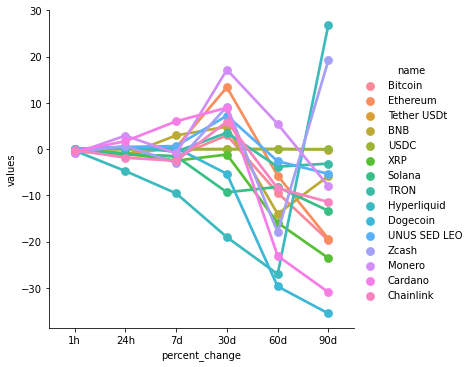

In [38]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point' )

In [39]:
# Now to do something much simpler
# we are going to create a dataframe with the columns we want

df10 = df[['name','quote.USD.price','timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,timestamp
0,Bitcoin,62979.16215,2026-08-01 10:30:13.804730
0,Bitcoin,62979.16215,NaT
0,Bitcoin,62981.39822,NaT


<AxesSubplot:xlabel='timestamp', ylabel='quote.USD.price'>

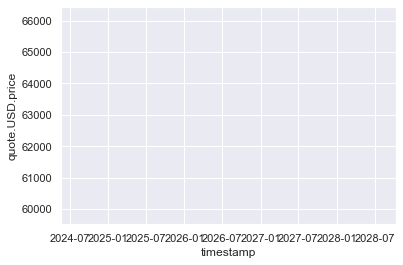

In [40]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='timestamp', y='quote.USD.price', data = df10)